## 1. Định nghĩa Vấn đề

## 2. Chuẩn bị vấn đề (Prepare Problem)

### 2.1 Tải thư viện

In [1]:
# Load libraries
import numpy
import pandas as pd
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

### 2.1. Nạp dữ liệu (Load Dataset)

In [2]:
# Load dataset
filename = '../data/raw/housing.csv'
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO',
'B', 'LSTAT', 'MEDV']
dataset = pd.read_csv(filename, names=names, index_col=0)

## 5. Cải thiện Độ chính xác

### 5.1 Tinh chỉnh Thuật toán

In [5]:
# Standardize the dataset
pipelines = [
    ('ScaledLR', Pipeline([('Scaler', StandardScaler()), ('LR', LinearRegression())])),
    ('ScaledLASSO', Pipeline([('Scaler', StandardScaler()), ('LASSO', Lasso())])),
    ('ScaledEN', Pipeline([('Scaler', StandardScaler()), ('EN', ElasticNet())])),
    ('ScaledKNN', Pipeline([('Scaler', StandardScaler()), ('KNN', KNeighborsRegressor())])),
    ('ScaledCART', Pipeline([('Scaler', StandardScaler()), ('CART', DecisionTreeRegressor())])),
    ('ScaledSVR', Pipeline([('Scaler', StandardScaler()), ('SVR', SVR())]))
]

results = []
names = []
# Guard: only run CV when training data is available to avoid NameError during static checks
if 'X_train' in globals() and 'Y_train' in globals():
    n_splits = num_folds if 'num_folds' in globals() else 3
    for name, model in pipelines:
        kfold = KFold(n_splits=n_splits)
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=(scoring if 'scoring' in globals() else None))
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)
else:
    print("X_train or Y_train not defined; skipping pipelines cross-validation")

X_train or Y_train not defined; skipping pipelines cross-validation


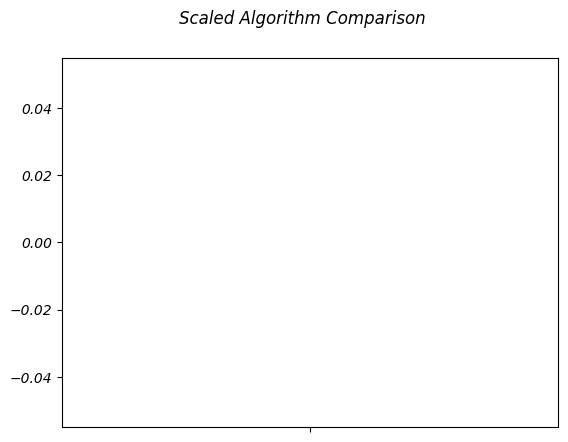

In [6]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

In [8]:
# KNN Algorithm tuning
if 'X_train' in globals() and 'Y_train' in globals():
    scaler = StandardScaler().fit(X_train)
    rescaledX = scaler.transform(X_train)
    k_values = numpy.array([1,3,5,7,9,11,13,15,17,19,21])
    param_grid = dict(n_neighbors=k_values)
    model = KNeighborsRegressor()
    n_splits = num_folds if 'num_folds' in globals() else 3
    kfold = KFold(n_splits=n_splits)
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=(scoring if 'scoring' in globals() else None), cv=kfold)
    grid_result = grid.fit(rescaledX, Y_train)
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    for mean, stdev, param in zip(means, stds, params):
        print("%f (%f) with: %r" % (mean, stdev, param))
else:
    print("X_train or Y_train not defined; skipping KNN grid search")

X_train or Y_train not defined; skipping KNN grid search


In [ ]:
# Print KNN grid search results (guarded)
if 'grid_result' in globals():
    # Print best score and params
    print(f"Best: {grid_result.best_score_} using {grid_result.best_params_}")
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    for mean, stdev, param in zip(means, stds, params):
        print(f"{mean:.6f} ({stdev:.6f}) with: {param!r}")
else:
    print("grid_result not defined; skipping KNN results print")

grid_result not defined; skipping KNN results print


### 5.2 

In [11]:
# ensembles
ensembles = [
    ('ScaledAB', Pipeline([('Scaler', StandardScaler()), ('AB', AdaBoostRegressor())])),
    ('ScaledGBM', Pipeline([('Scaler', StandardScaler()), ('GBM', GradientBoostingRegressor())])),
    ('ScaledRF', Pipeline([('Scaler', StandardScaler()), ('RF', RandomForestRegressor())])),
    ('ScaledET', Pipeline([('Scaler', StandardScaler()), ('ET', ExtraTreesRegressor())]))
]

results = []
names = []
if 'X_train' in globals() and 'Y_train' in globals():
    n_splits = num_folds if 'num_folds' in globals() else 3
    for name, model in ensembles:
        kfold = KFold(n_splits=n_splits)
        cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=(scoring if 'scoring' in globals() else None))
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
        print(msg)
else:
    print("X_train or Y_train not defined; skipping ensembles cross-validation")

X_train or Y_train not defined; skipping ensembles cross-validation


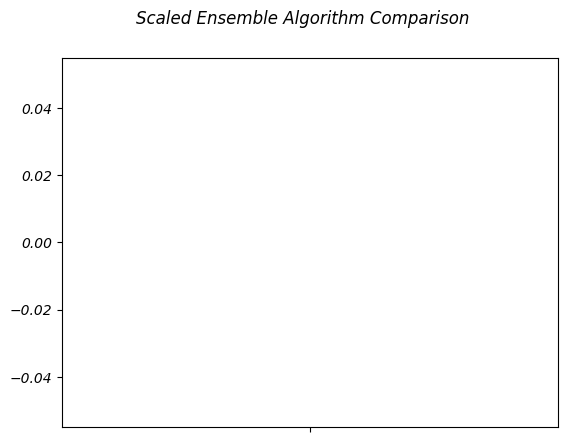

In [12]:
# Compare Algorithms
fig = pyplot.figure()
fig.suptitle('Scaled Ensemble Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
pyplot.show()

In [13]:
# Tune scaled GBM (guarded)
if 'X_train' in globals() and 'Y_train' in globals():
    scaler = StandardScaler().fit(X_train)
    rescaledX = scaler.transform(X_train)
    param_grid = dict(n_estimators=numpy.array([50,100,150,200,250,300,350,400]))
    model = GradientBoostingRegressor(random_state=(seed if 'seed' in globals() else None))
    n_splits = num_folds if 'num_folds' in globals() else 3
    kfold = KFold(n_splits=n_splits)
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=(scoring if 'scoring' in globals() else None), cv=kfold)
    grid_result = grid.fit(rescaledX, Y_train)
    print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
    means = grid_result.cv_results_['mean_test_score']
    stds = grid_result.cv_results_['std_test_score']
    params = grid_result.cv_results_['params']
    for mean, stdev, param in zip(means, stds, params):
        print("%f (%f) with: %r" % (mean, stdev, param))
else:
    print("X_train or Y_train not defined; skipping GBM grid search")

X_train or Y_train not defined; skipping GBM grid search
